# Практичний ноутбук: використання **LSTM** та **GRU** для аналізу тексту

## Тема
У цьому ноутбуці ми порівняємо дві популярні рекурентні архітектури:
- **LSTM (Long Short-Term Memory)**
- **GRU (Gated Recurrent Unit)**

на задачі **sentiment analysis** для датасету **IMDb**.

## Мета роботи
Після виконання ноутбука ви зможете:
- підготувати текстові послідовності для рекурентних моделей
- побудувати моделі `Embedding + LSTM + Dense` та `Embedding + GRU + Dense`
- натренувати обидві моделі
- порівняти їх за:
  - `loss`
  - `accuracy`
  - часом навчання
- зробити висновки щодо відмінностей LSTM і GRU

## Що демонструє цей приклад
- як працюють sequence-моделі у Keras
- чому LSTM і GRU підходять для тексту
- як порівнювати архітектури на одній і тій самій задачі


In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import classification_report, confusion_matrix

np.random.seed(42)
keras.utils.set_random_seed(42)


## 1. Завантаження датасету IMDb

IMDb — це набір текстових відгуків:
- `1` — позитивний відгук
- `0` — негативний відгук

Тексти вже подані як **послідовності індексів слів**.


In [3]:
VOCAB_SIZE = 10000

(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=VOCAB_SIZE)

print("Train examples:", len(x_train))
print("Test examples :", len(x_test))
print("Довжина першого train прикладу:", len(x_train[0]))
print("Перші 20 токенів:", x_train[0][:20])
print("Мітка:", y_train[0])


c:\Users\SystemX\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


Train examples: 25000
Test examples : 25000
Довжина першого train прикладу: 218
Перші 20 токенів: [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]
Мітка: 1


## 2. Паддинг послідовностей

Для пакетного навчання вирівнюємо всі послідовності до однакової довжини.


In [4]:
MAX_LEN = 200

x_train_pad = pad_sequences(x_train, maxlen=MAX_LEN, padding="pre", truncating="pre")
x_test_pad = pad_sequences(x_test, maxlen=MAX_LEN, padding="pre", truncating="pre")

print("x_train_pad shape:", x_train_pad.shape)
print("x_test_pad shape :", x_test_pad.shape)


x_train_pad shape: (25000, 200)
x_test_pad shape : (25000, 200)


## 3. Відновлення тексту з токенів

Це корисно для розуміння того, як виглядає вхід до моделі.


In [5]:
word_index = keras.datasets.imdb.get_word_index()
reverse_word_index = {value + 3: key for key, value in word_index.items()}
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

def decode_review(encoded_review):
    return " ".join(reverse_word_index.get(i, "?") for i in encoded_review)

print(decode_review(x_train[0][:50]))


1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved


## 4. Побудова моделей

Щоб порівняння було чесним, для обох моделей використаємо однаковий pipeline:

- `Embedding(10000, 64)`
- рекурентний шар (`LSTM(64)` або `GRU(64)`)
- `Dense(1, sigmoid)`

Відрізняється лише тип рекурентного шару.


In [6]:
def build_lstm_model():
    model = keras.Sequential([
        keras.Input(shape=(MAX_LEN,)),
        layers.Embedding(input_dim=VOCAB_SIZE, output_dim=64),
        layers.LSTM(64),
        layers.Dense(1, activation="sigmoid")
    ], name="lstm_imdb")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

def build_gru_model():
    model = keras.Sequential([
        keras.Input(shape=(MAX_LEN,)),
        layers.Embedding(input_dim=VOCAB_SIZE, output_dim=64),
        layers.GRU(64),
        layers.Dense(1, activation="sigmoid")
    ], name="gru_imdb")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

lstm_model = build_lstm_model()
gru_model = build_gru_model()

print("=== LSTM ===")
lstm_model.summary()

print("\n=== GRU ===")
gru_model.summary()


=== LSTM ===


Model: "lstm_imdb"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,089 (2.57 MB)

 Trainable params: 673,089 (2.57 MB)

...

Model: "gru_imdb"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 665,025 (2.54 MB)

 Trainable params: 665,025 (2.54 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Навчання моделей


In [7]:
EPOCHS = 5
BATCH_SIZE = 128


In [8]:
# Навчання LSTM
start = time.time()
history_lstm = lstm_model.fit(
    x_train_pad, y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)
time_lstm = time.time() - start

test_loss_lstm, test_acc_lstm = lstm_model.evaluate(x_test_pad, y_test, verbose=0)

print(f"LSTM test loss: {test_loss_lstm:.4f}")
print(f"LSTM test acc : {test_acc_lstm:.4f}")
print(f"LSTM training time: {time_lstm:.2f} sec")


Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 72ms/step - accuracy: 0.7818 - loss: 0.4431 - val_accuracy: 0.8730 - val_loss: 0.3082
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 68ms/step - accuracy: 0.9079 - loss: 0.2375 - val_accuracy: 0.8690 - val_loss: 0.3151
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 68ms/step - accuracy: 0.9191 - loss: 0.2163 - val_accuracy: 0.8532 - val_loss: 0.3344
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 69ms/step - accuracy: 0.9247 - loss: 0.1925 - val_accuracy: 0.8350 - val_loss: 0.3964
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 69ms/step - accuracy: 0.9288 - loss: 0.1858 - val_accuracy: 0.8782 - val_loss: 0.3548
LSTM test loss: 0.3900
LSTM test acc : 0.8640
LSTM training time: 55.81 sec


In [9]:
# Навчання GRU
start = time.time()
history_gru = gru_model.fit(
    x_train_pad, y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)
time_gru = time.time() - start

test_loss_gru, test_acc_gru = gru_model.evaluate(x_test_pad, y_test, verbose=0)

print(f"GRU test loss: {test_loss_gru:.4f}")
print(f"GRU test acc : {test_acc_gru:.4f}")
print(f"GRU training time: {time_gru:.2f} sec")


Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 68ms/step - accuracy: 0.7362 - loss: 0.4983 - val_accuracy: 0.8516 - val_loss: 0.3583
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.8898 - loss: 0.2745 - val_accuracy: 0.8476 - val_loss: 0.3780
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.9161 - loss: 0.2187 - val_accuracy: 0.8474 - val_loss: 0.3546
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.9295 - loss: 0.1862 - val_accuracy: 0.8378 - val_loss: 0.4533
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 65ms/step - accuracy: 0.9316 - loss: 0.1815 - val_accuracy: 0.8616 - val_loss: 0.4830
GRU test loss: 0.5391
GRU test acc : 0.8434
GRU training time: 52.66 sec


## 6. Графіки навчання


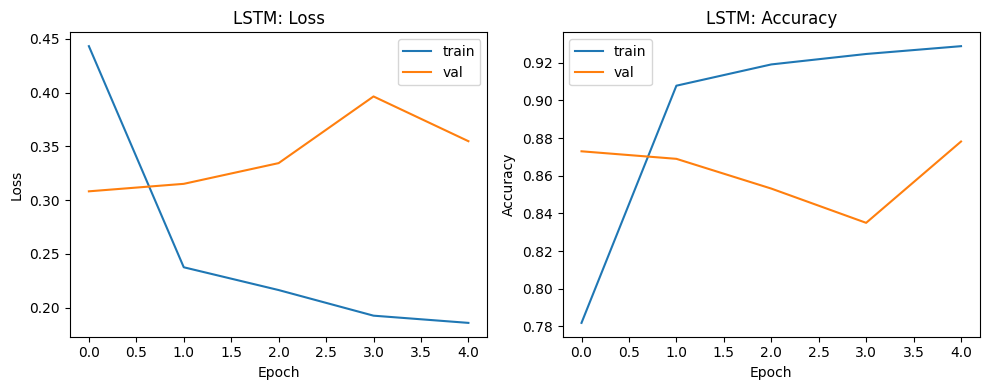

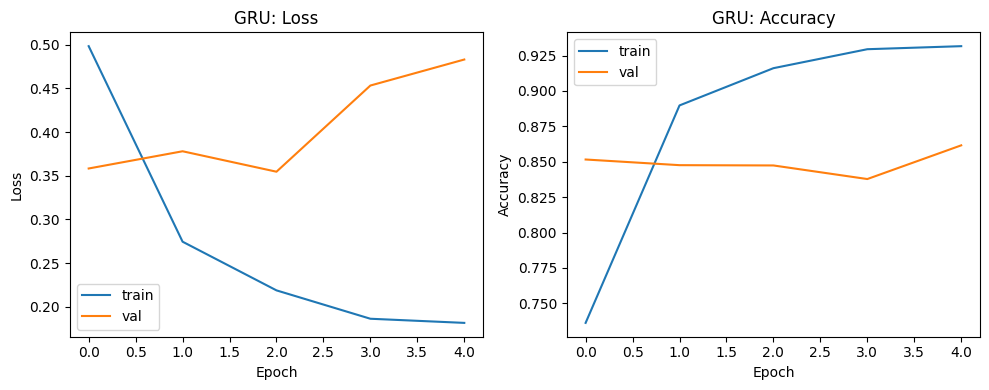

In [10]:
def plot_history(hist, title_prefix=""):
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.plot(hist.history["loss"], label="train")
    plt.plot(hist.history["val_loss"], label="val")
    plt.title(f"{title_prefix}Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(hist.history["accuracy"], label="train")
    plt.plot(hist.history["val_accuracy"], label="val")
    plt.title(f"{title_prefix}Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history_lstm, "LSTM: ")
plot_history(history_gru, "GRU: ")


## 7. Порівняння результатів


In [11]:
summary = [
    {
        "Model": "LSTM",
        "Test loss": round(float(test_loss_lstm), 4),
        "Test acc": round(float(test_acc_lstm), 4),
        "Train time (sec)": round(float(time_lstm), 2)
    },
    {
        "Model": "GRU",
        "Test loss": round(float(test_loss_gru), 4),
        "Test acc": round(float(test_acc_gru), 4),
        "Train time (sec)": round(float(time_gru), 2)
    }
]

summary


[{'Model': 'LSTM',
  'Test loss': 0.39,
  'Test acc': 0.864,
  'Train time (sec)': 55.81},
 {'Model': 'GRU',
  'Test loss': 0.5391,
  'Test acc': 0.8434,
  'Train time (sec)': 52.66}]

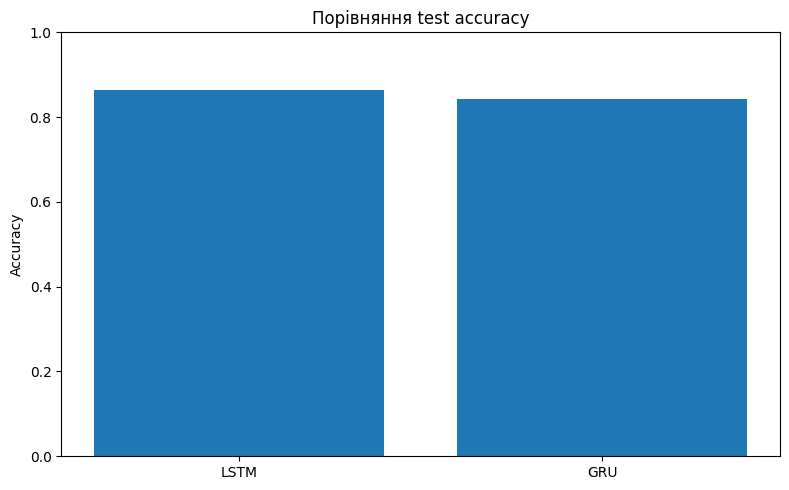

In [12]:
models = [row["Model"] for row in summary]
test_accs = [row["Test acc"] for row in summary]

plt.figure(figsize=(8, 5))
plt.bar(models, test_accs)
plt.title("Порівняння test accuracy")
plt.ylabel("Accuracy")
plt.ylim(0, 1.0)
plt.tight_layout()
plt.show()


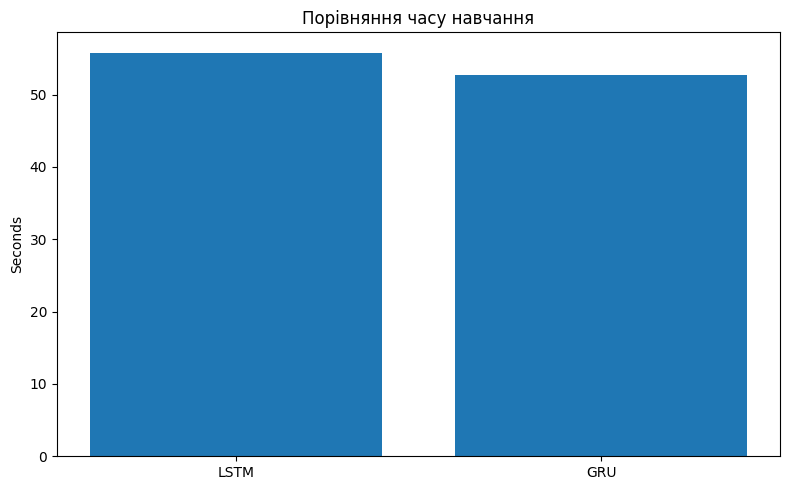

In [13]:
train_times = [row["Train time (sec)"] for row in summary]

plt.figure(figsize=(8, 5))
plt.bar(models, train_times)
plt.title("Порівняння часу навчання")
plt.ylabel("Seconds")
plt.tight_layout()
plt.show()


## 8. Детальний аналіз для найкращої моделі


In [14]:
best_name = "LSTM" if test_acc_lstm >= test_acc_gru else "GRU"
best_model = lstm_model if test_acc_lstm >= test_acc_gru else gru_model

print("Найкраща модель:", best_name)


Найкраща модель: LSTM


In [15]:
y_prob = best_model.predict(x_test_pad, verbose=0).flatten()
y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(y_test, y_pred, digits=4))


              precision    recall  f1-score   support

           0     0.8503    0.8834    0.8666     12500
           1     0.8787    0.8445    0.8613     12500

    accuracy                         0.8640     25000
   macro avg     0.8645    0.8640    0.8639     25000
weighted avg     0.8645    0.8640    0.8639     25000



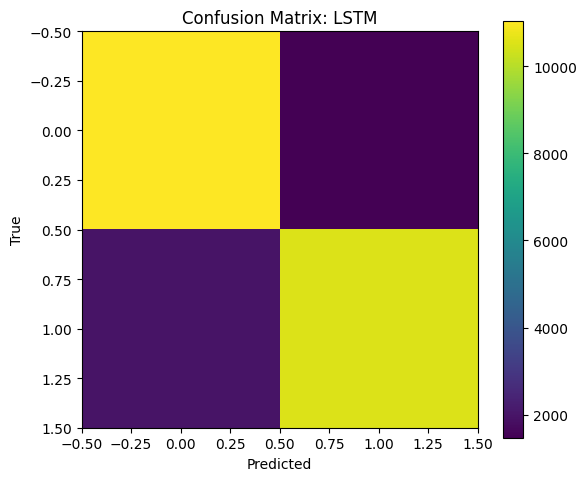

In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title(f"Confusion Matrix: {best_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.tight_layout()
plt.show()


## 9. Приклади прогнозів


In [17]:
sample_probs = best_model.predict(x_test_pad[:10], verbose=0).flatten()
sample_preds = (sample_probs >= 0.5).astype(int)

for i in range(5):
    print(f"Приклад {i}: true={y_test[i]}, pred={sample_preds[i]}, prob={sample_probs[i]:.4f}")


Приклад 0: true=0, pred=0, prob=0.0377
Приклад 1: true=1, pred=1, prob=0.9980
Приклад 2: true=1, pred=1, prob=0.9720
Приклад 3: true=0, pred=0, prob=0.3859
Приклад 4: true=1, pred=1, prob=0.9998


## 10. Інтерпретація результатів

### Що зазвичай спостерігається
- **LSTM** часто трохи точніша на довших залежностях
- **GRU** часто навчається швидше
- обидві архітектури значно сильніші за просту RNN на текстових послідовностях

### Відмінність архітектур
**LSTM**
- має `cell state`
- має три основні ворота
- складніша, але потужніша

**GRU**
- простіша архітектурно
- має менше параметрів
- часто працює швидше


# TO DO для студентів

## Завдання 1
Змініть довжину послідовності:
- `MAX_LEN = 100`
- `MAX_LEN = 300`

## Завдання 2
Змініть кількість нейронів:
- `LSTM(32)` / `GRU(32)`
- `LSTM(128)` / `GRU(128)`

## Завдання 3
Додайте:
- `Dropout`
- `recurrent_dropout`

## Завдання 4
Спробуйте:
- `Bidirectional(LSTM(...))`
- `Bidirectional(GRU(...))`

## Завдання 5
Додайте `EarlyStopping` і порівняйте результати.


## 11. Заготовки для додаткових експериментів


In [18]:
# Bidirectional LSTM
# model_bilstm = keras.Sequential([
#     keras.Input(shape=(MAX_LEN,)),
#     layers.Embedding(input_dim=VOCAB_SIZE, output_dim=64),
#     layers.Bidirectional(layers.LSTM(64)),
#     layers.Dense(1, activation="sigmoid")
# ])
#
# model_bilstm.compile(
#     optimizer=keras.optimizers.Adam(learning_rate=1e-3),
#     loss="binary_crossentropy",
#     metrics=["accuracy"]
# )


In [19]:
# Bidirectional GRU
# model_bigru = keras.Sequential([
#     keras.Input(shape=(MAX_LEN,)),
#     layers.Embedding(input_dim=VOCAB_SIZE, output_dim=64),
#     layers.Bidirectional(layers.GRU(64)),
#     layers.Dense(1, activation="sigmoid")
# ])
#
# model_bigru.compile(
#     optimizer=keras.optimizers.Adam(learning_rate=1e-3),
#     loss="binary_crossentropy",
#     metrics=["accuracy"]
# )


## 12. Виконання TO DO-завдань

Тут ми виконаємо завдання з розділу `TO DO для студентів` і покажемо результати експериментів з різними налаштуваннями моделей.

### Завдання 1: зміна довжини послідовності

Порівняємо результати для `MAX_LEN = 100` та `MAX_LEN = 300` на обох моделях: `LSTM` та `GRU`.

In [20]:
def run_length_experiment(lengths, epochs=3, batch_size=128):
    results = []

    def build_model(cell, max_len):
        inputs = keras.Input(shape=(max_len,))
        x = layers.Embedding(input_dim=VOCAB_SIZE, output_dim=64)(inputs)
        if cell == "lstm":
            x = layers.LSTM(64)(x)
        else:
            x = layers.GRU(64)(x)
        outputs = layers.Dense(1, activation="sigmoid")(x)
        model = keras.Model(inputs, outputs)
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=1e-3),
            loss="binary_crossentropy",
            metrics=["accuracy"]
        )
        return model

    for max_len in lengths:
        x_train_pad = pad_sequences(x_train, maxlen=max_len, padding="pre", truncating="pre")
        x_test_pad = pad_sequences(x_test, maxlen=max_len, padding="pre", truncating="pre")

        for cell_type in ["lstm", "gru"]:
            model = build_model(cell_type, max_len)
            history = model.fit(
                x_train_pad, y_train,
                validation_split=0.2,
                epochs=epochs,
                batch_size=batch_size,
                verbose=1
            )
            test_loss, test_acc = model.evaluate(x_test_pad, y_test, verbose=0)
            results.append({
                "max_len": max_len,
                "cell": cell_type.upper(),
                "test_loss": float(test_loss),
                "test_acc": float(test_acc)
            })
    return results

length_results = run_length_experiment([100, 300], epochs=3)
length_results

Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.7588 - loss: 0.4813 - val_accuracy: 0.8448 - val_loss: 0.3536
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.8875 - loss: 0.2822 - val_accuracy: 0.8424 - val_loss: 0.3544
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.9097 - loss: 0.2356 - val_accuracy: 0.8400 - val_loss: 0.4276
Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.7388 - loss: 0.4930 - val_accuracy: 0.8374 - val_loss: 0.3659
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.8835 - loss: 0.2831 - val_accuracy: 0.8438 - val_loss: 0.3861
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.9101 - loss: 0.2350 - val_accuracy: 0.8390 - val_loss: 0.4060
Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 119ms/step - accuracy: 0.7724 - loss: 0.4649 - val_accuracy: 0.8608 - val_loss: 0.3268
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 116ms/step - accuracy: 0.9013 - loss: 0.2505 - val_accuracy

[{'max_len': 100,
  'cell': 'LSTM',
  'test_loss': 0.43178507685661316,
  'test_acc': 0.8381999731063843},
 {'max_len': 100,
  'cell': 'GRU',
  'test_loss': 0.41209378838539124,
  'test_acc': 0.8351200222969055},
 {'max_len': 300,
  'cell': 'LSTM',
  'test_loss': 0.3530571758747101,
  'test_acc': 0.8521199822425842},
 {'max_len': 300,
  'cell': 'GRU',
  'test_loss': 0.3667495846748352,
  'test_acc': 0.8410400152206421}]

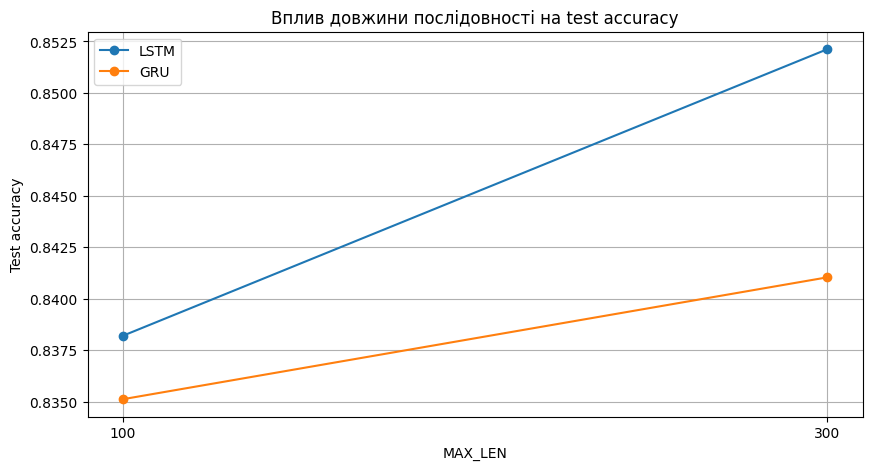

In [21]:
plt.figure(figsize=(10, 5))
for cell_type in ["LSTM", "GRU"]:
    subset = [r for r in length_results if r["cell"] == cell_type]
    subset.sort(key=lambda r: r["max_len"])
    plt.plot([r["max_len"] for r in subset], [r["test_acc"] for r in subset], marker="o", label=cell_type)

plt.title("Вплив довжини послідовності на test accuracy")
plt.xlabel("MAX_LEN")
plt.ylabel("Test accuracy")
plt.xticks([100, 300])
plt.legend()

plt.grid(True)
plt.show()

### Завдання 2: зміна кількості нейронів

Порівняємо `LSTM(32)` / `GRU(32)` та `LSTM(128)` / `GRU(128)` з фіксованою довжиною послідовності `MAX_LEN = 200`.

In [22]:
def run_unit_experiment(units_list, epochs=3, batch_size=128):
    results = []

    def build_model(cell, units):
        model = keras.Sequential([
            keras.Input(shape=(MAX_LEN,)),
            layers.Embedding(input_dim=VOCAB_SIZE, output_dim=64),
            layers.LSTM(units) if cell == "lstm" else layers.GRU(units),
            layers.Dense(1, activation="sigmoid")
        ])
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=1e-3),
            loss="binary_crossentropy",
            metrics=["accuracy"]
        )
        return model

    for units in units_list:
        for cell_type in ["lstm", "gru"]:
            model = build_model(cell_type, units)
            history = model.fit(
                x_train_pad, y_train,
                validation_split=0.2,
                epochs=epochs,
                batch_size=batch_size,
                verbose=1
            )
            test_loss, test_acc = model.evaluate(x_test_pad, y_test, verbose=0)
            results.append({
                "units": units,
                "cell": cell_type.upper(),
                "test_loss": float(test_loss),
                "test_acc": float(test_acc)
            })
    return results

unit_results = run_unit_experiment([32, 128], epochs=3)
unit_results

Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.7404 - loss: 0.5121 - val_accuracy: 0.8198 - val_loss: 0.4026
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.8910 - loss: 0.2764 - val_accuracy: 0.8528 - val_loss: 0.3370
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.9295 - loss: 0.1942 - val_accuracy: 0.8506 - val_loss: 0.3524
Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 0.7232 - loss: 0.5225 - val_accuracy: 0.8340 - val_loss: 0.3757
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.8792 - loss: 0.2960 - val_accuracy: 0.8596 - val_loss: 0.3441
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.9227 - loss: 0.2112 - val_accuracy: 0.8474 - val_loss: 0.3835
Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 121ms/step - accuracy: 0.7538 - loss: 0.4954 - val_accuracy: 0.8426 - val_loss: 0.3676
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 111ms/step - accuracy: 0.8760 - loss: 0.3051 - val_accuracy

[{'units': 32,
  'cell': 'LSTM',
  'test_loss': 0.36452019214630127,
  'test_acc': 0.8472800254821777},
 {'units': 32,
  'cell': 'GRU',
  'test_loss': 0.3876258134841919,
  'test_acc': 0.8443999886512756},
 {'units': 128,
  'cell': 'LSTM',
  'test_loss': 0.3461476266384125,
  'test_acc': 0.8558800220489502},
 {'units': 128,
  'cell': 'GRU',
  'test_loss': 0.3647356331348419,
  'test_acc': 0.8452399969100952}]

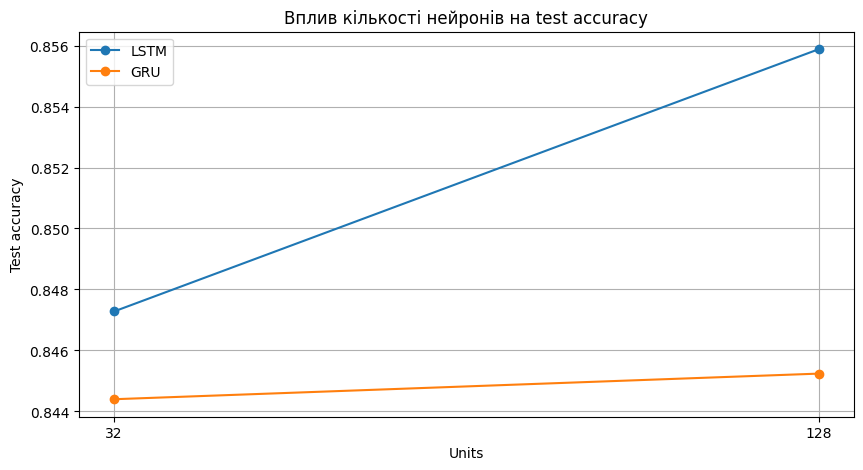

In [23]:
plt.figure(figsize=(10, 5))
for cell_type in ["LSTM", "GRU"]:
    subset = [r for r in unit_results if r["cell"] == cell_type]
    subset.sort(key=lambda r: r["units"])
    plt.plot([r["units"] for r in subset], [r["test_acc"] for r in subset], marker="o", label=cell_type)

plt.title("Вплив кількості нейронів на test accuracy")
plt.xlabel("Units")
plt.ylabel("Test accuracy")
plt.xticks([32, 128])
plt.legend()

plt.grid(True)
plt.show()

### Завдання 3: додайте Dropout та recurrent_dropout

Побудуємо моделі з `SpatialDropout1D` та `recurrent_dropout=0.2` для LSTM та GRU.

In [ ]:
def run_dropout_experiment(epochs=4, batch_size=128):
    results = []

    def build_model(cell):
        model = keras.Sequential([
            keras.Input(shape=(MAX_LEN,)),
            layers.Embedding(input_dim=VOCAB_SIZE, output_dim=64),
            layers.SpatialDropout1D(0.2),
            layers.LSTM(64, dropout=0.2, recurrent_dropout=0.2) if cell == "lstm" else layers.GRU(64, dropout=0.2, recurrent_dropout=0.2),
            layers.Dense(1, activation="sigmoid")
        ])
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=1e-3),
            loss="binary_crossentropy",
            metrics=["accuracy"]
        )
        return model

    for cell_type in ["lstm", "gru"]:
        model = build_model(cell_type)
        history = model.fit(
            x_train_pad, y_train,
            validation_split=0.2,
            epochs=epochs,
            batch_size=batch_size,
            verbose=1
        )
        test_loss, test_acc = model.evaluate(x_test_pad, y_test, verbose=0)
        results.append({
            "cell": cell_type.upper(),
            "test_loss": float(test_loss),
            "test_acc": float(test_acc)
        })
    return results

dropout_results = run_dropout_experiment()
pd.DataFrame(dropout_results)

Epoch 1/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 35s 209ms/step - accuracy: 0.7214 - loss: 0.5423 - val_accuracy: 0.8152 - val_loss: 0.4099
Epoch 2/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 29s 186ms/step - accuracy: 0.8438 - loss: 0.3637 - val_accuracy: 0.7814 - val_loss: 0.4572
Epoch 3/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 30s 191ms/step - accuracy: 0.8763 - loss: 0.3080 - val_accuracy: 0.8200 - val_loss: 0.3917
Epoch 4/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 34s 219ms/step - accuracy: 0.9009 - loss: 0.2540 - val_accuracy: 0.8296 - val_loss: 0.3907


In [ ]:
plt.figure(figsize=(6, 4))
plt.bar([row["cell"] for row in dropout_results], [row["test_acc"] for row in dropout_results], color=["tab:blue", "tab:orange"])
plt.title("Test accuracy з Dropout / recurrent_dropout")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

### Завдання 4: Bidirectional LSTM та GRU

Спробуємо `Bidirectional(LSTM(64))` та `Bidirectional(GRU(64))` на тій же довжині `MAX_LEN = 200`.

In [ ]:
def run_bidirectional_experiment(epochs=3, batch_size=128):
    results = []

    for cell_type in ["lstm", "gru"]:
        model = keras.Sequential([
            keras.Input(shape=(MAX_LEN,)),
            layers.Embedding(input_dim=VOCAB_SIZE, output_dim=64),
            layers.Bidirectional(layers.LSTM(64)) if cell_type == "lstm" else layers.Bidirectional(layers.GRU(64)),
            layers.Dense(1, activation="sigmoid")
        ])
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=1e-3),
            loss="binary_crossentropy",
            metrics=["accuracy"]
        )
        model.fit(
            x_train_pad, y_train,
            validation_split=0.2,
            epochs=epochs,
            batch_size=batch_size,
            verbose=1
        )
        test_loss, test_acc = model.evaluate(x_test_pad, y_test, verbose=0)
        results.append({
            "cell": f"BIDIR_{cell_type.upper()}",
            "test_loss": float(test_loss),
            "test_acc": float(test_acc)
        })
    return results

bidir_results = run_bidirectional_experiment()
pd.DataFrame(bidir_results)

### Завдання 5: додайте EarlyStopping

Навчимо модель з `EarlyStopping`, щоб побачити, як рання зупинка впливає на якість і тривалість тренування.

In [ ]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
    verbose=1
)

model_es = keras.Sequential([
    keras.Input(shape=(MAX_LEN,)),
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=64),
    layers.LSTM(64),
    layers.Dense(1, activation="sigmoid")
])
model_es.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_es = model_es.fit(
    x_train_pad, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

es_test_loss, es_test_acc = model_es.evaluate(x_test_pad, y_test, verbose=0)
print(f"EarlyStopping stop epoch: {len(history_es.history['loss'])}")
print(f"Test loss: {es_test_loss:.4f}")
print(f"Test acc : {es_test_acc:.4f}")

In [ ]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_es.history["loss"], label="train")
plt.plot(history_es.history["val_loss"], label="val")
plt.title("EarlyStopping Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_es.history["accuracy"], label="train")
plt.plot(history_es.history["val_accuracy"], label="val")
plt.title("EarlyStopping Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

# Підсумок

У цьому ноутбуці ми:
- підготували текстові послідовності
- побудували **LSTM** і **GRU**
- порівняли їх на задачі **sentiment analysis**
- проаналізували якість, графіки навчання та час виконання

Це базовий практичний приклад для подальшого переходу до:
- **Bidirectional RNN**
- **Attention**
- **Transformer-моделей**
